In [20]:
import os, cv2, shutil, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [21]:
import os

base_dir = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"
print(os.listdir(base_dir))

['no', 'yes']


In [22]:
def create_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    blur = cv2.GaussianBlur(gray, (7,7), 0)
    
    _, thresh = cv2.threshold(blur, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return thresh

In [23]:
def extract_roi(img, mask):
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return img
    
    c = max(contours, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)
    
    return img[y:y+h, x:x+w]

In [24]:
roi_dir = "/kaggle/working/roi_dataset"

for cls in ['yes', 'no']:
    os.makedirs(os.path.join(roi_dir, cls), exist_ok=True)
    
    img_list = os.listdir(os.path.join(base_dir, cls))
    
    for img_name in img_list:
        img_path = os.path.join(base_dir, cls, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.resize(img, (224,224))
        
        mask = create_mask(img)
        roi = extract_roi(img, mask)
        
        roi = cv2.resize(roi, (224,224))
        
        cv2.imwrite(os.path.join(roi_dir, cls, img_name), roi)

In [25]:
train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_gen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [26]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5080 - loss: 0.7954 - val_accuracy: 0.3800 - val_loss: 0.7027
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.6105 - loss: 0.6952 - val_accuracy: 0.6200 - val_loss: 0.6513
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.5923 - loss: 0.7329 - val_accuracy: 0.7200 - val_loss: 0.6444
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.6419 - loss: 0.6589 - val_accuracy: 0.6400 - val_loss: 0.6116
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6953 - loss: 0.6156 - val_accuracy: 0.6800 - val_loss: 0.6062
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.7045 - loss: 0.5869 - val_accuracy: 0.6800 - val_loss: 0.5755
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.7503 - loss: 0.5600 - val_accuracy: 0.6400 - val_loss: 0.5735
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.7344 - loss: 0.5468 - val_accuracy: 0.7000 - val_loss: 0

In [27]:
roi_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

roi_train = roi_gen.flow_from_directory(
    roi_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

roi_val = roi_gen.flow_from_directory(
    roi_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [28]:
roi_model = models.Sequential([
    layers.Conv2D(32,3,activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

roi_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

roi_model.fit(roi_train, validation_data=roi_val, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.5903 - loss: 3.5736 - val_accuracy: 0.5400 - val_loss: 0.6845
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7198 - loss: 0.5978 - val_accuracy: 0.6000 - val_loss: 0.6335
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8041 - loss: 0.5133 - val_accuracy: 0.6400 - val_loss: 0.9118
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8478 - loss: 0.3461 - val_accuracy: 0.7200 - val_loss: 0.5473
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9744 - loss: 0.1803 - val_accuracy: 0.6400 - val_loss: 0.5882
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9729 - loss: 0.1177 - val_accuracy: 0.7600 - val_loss: 0.6637
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9924 - loss: 0.0462 - val_accuracy: 0.6800 - val_loss: 0.7459
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9988 - loss: 0.0259 - val_accuracy: 0.7200 - val_loss: 0.9397
Epoch 9/10

In [29]:
from sklearn.metrics import classification_report

# RESNET
y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int)

print("FULL IMAGE MODEL")
print(classification_report(val_data.classes, y_pred))

# ROI
roi_pred = roi_model.predict(roi_val)
roi_pred = (roi_pred > 0.5).astype(int)

print("ROI MODEL")
print(classification_report(roi_val.classes, roi_pred))

1/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d34ac3ea660> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
FULL IMAGE MODEL
              precision    recall  f1-score   support

           0       0.39      0.37      0.38        19
           1       0.62      0.65      0.63        31

    accuracy              

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


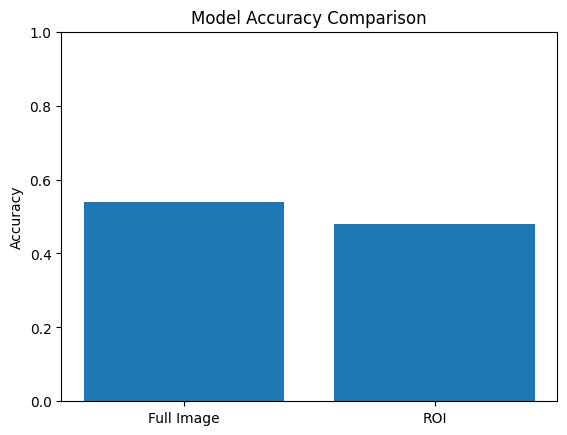

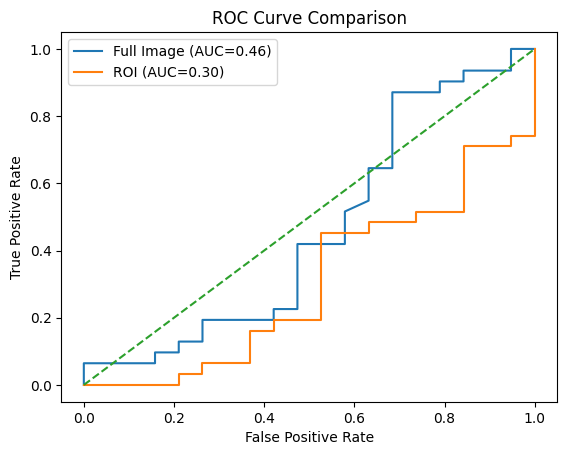

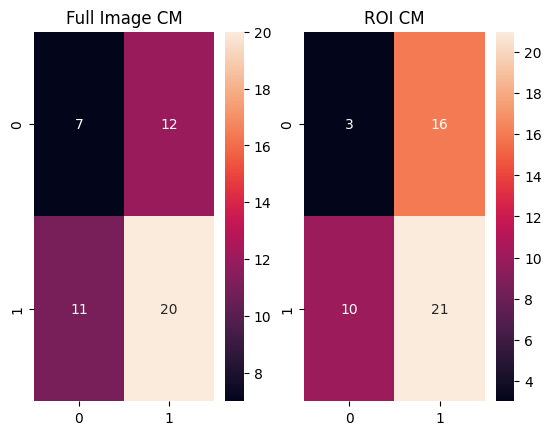

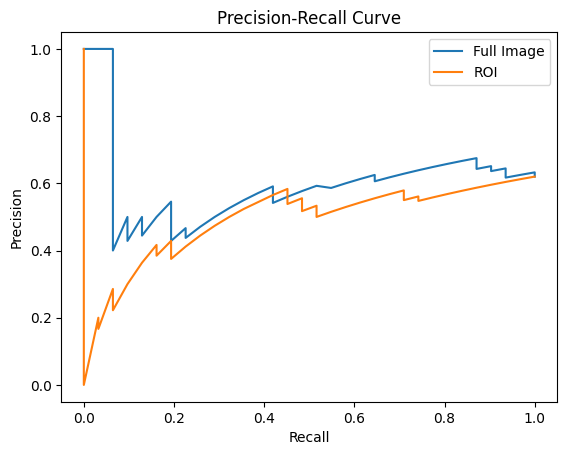

FULL IMAGE MODEL
              precision    recall  f1-score   support

           0       0.39      0.37      0.38        19
           1       0.62      0.65      0.63        31

    accuracy                           0.54        50
   macro avg       0.51      0.51      0.51        50
weighted avg       0.54      0.54      0.54        50

ROI MODEL
              precision    recall  f1-score   support

           0       0.23      0.16      0.19        19
           1       0.57      0.68      0.62        31

    accuracy                           0.48        50
   macro avg       0.40      0.42      0.40        50
weighted avg       0.44      0.48      0.45        50



In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
import seaborn as sns

# ------------------------
# 1. PREDICTIONS
# ------------------------

# FULL IMAGE
y_true_full = val_data.classes
y_prob_full = model.predict(val_data)
y_pred_full = (y_prob_full > 0.5).astype(int)

# ROI
y_true_roi = roi_val.classes
y_prob_roi = roi_model.predict(roi_val)
y_pred_roi = (y_prob_roi > 0.5).astype(int)

# ------------------------
# 2. ACCURACY
# ------------------------

acc_full = np.mean(y_pred_full.flatten() == y_true_full)
acc_roi = np.mean(y_pred_roi.flatten() == y_true_roi)

plt.figure()
plt.bar(["Full Image", "ROI"], [acc_full, acc_roi])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ------------------------
# 3. ROC CURVE
# ------------------------

fpr_full, tpr_full, _ = roc_curve(y_true_full, y_prob_full)
fpr_roi, tpr_roi, _ = roc_curve(y_true_roi, y_prob_roi)

auc_full = auc(fpr_full, tpr_full)
auc_roi = auc(fpr_roi, tpr_roi)

plt.figure()
plt.plot(fpr_full, tpr_full, label=f"Full Image (AUC={auc_full:.2f})")
plt.plot(fpr_roi, tpr_roi, label=f"ROI (AUC={auc_roi:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ------------------------
# 4. CONFUSION MATRIX
# ------------------------

cm_full = confusion_matrix(y_true_full, y_pred_full)
cm_roi = confusion_matrix(y_true_roi, y_pred_roi)

fig, axes = plt.subplots(1, 2)

sns.heatmap(cm_full, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Full Image CM")

sns.heatmap(cm_roi, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("ROI CM")

plt.show()

# ------------------------
# 5. PRECISION-RECALL CURVE
# ------------------------

prec_full, rec_full, _ = precision_recall_curve(y_true_full, y_prob_full)
prec_roi, rec_roi, _ = precision_recall_curve(y_true_roi, y_prob_roi)

plt.figure()
plt.plot(rec_full, prec_full, label="Full Image")
plt.plot(rec_roi, prec_roi, label="ROI")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ------------------------
# 6. CLASSIFICATION REPORT
# ------------------------

print("FULL IMAGE MODEL")
print(classification_report(y_true_full, y_pred_full))

print("ROI MODEL")
print(classification_report(y_true_roi, y_pred_roi))